In [1]:
%matplotlib inline
import sys
import yaml
from IPython.display import Code
import pcse
from datetime import datetime, timedelta
import pprint
import pandas as pd
import numpy as np
import matplotlib
matplotlib.style.use("ggplot")
import matplotlib.pyplot as plt
import os
import xarray as xr
import pickle
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

import imageio
import os
from pathlib import Path

/Users/nadiatestani/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
#GIF 

temp_dir = "methodology_outs/scenario_plots"

# Lista de escenarios y períodos
scenarios = ["rcp26", "rcp45", "rcp85"]
periods = ["2021_2050","2031_2060","2041_2070","2051_2080","2061_2090","2071_2099"]

# Para cada escenario
for scenario in scenarios:
    images = []
    
    # Para cada período
    for period_idx, period in enumerate(periods):
        # Cargar datos del CSV
        df_changes = pd.read_csv(f"methodology_outs/{scenario}_{period}_meanChanges_Foulum.csv")
        
        # Crear el plot
        plt.figure(figsize=(7, 5), dpi=700)
        
        # KDE plot
        def truncate_colormap(cmap, minval=0.4, maxval=0.9, n=100):
            return LinearSegmentedColormap.from_list(
                "trunc_greys", cmap(np.linspace(minval, maxval, n))
            )
        trunc_greys = truncate_colormap(plt.cm.Greys, 0.4, 0.9)
        
        ax = sns.kdeplot(
            x=df_changes['t_change'],
            y=df_changes['pp_change'],
            cmap=trunc_greys,
            fill=True, alpha=0.6,
            levels=[0.1, 0.25, 0.5, 0.75, 0.95, 1],
            thresh=0.0,
            common_norm=False
        )
        
        # Scatter points
        plt.scatter(
            df_changes['t_change'],
            df_changes['pp_change'],
            color="k", edgecolor="k", s=12, marker="o", alpha=0.4
        )
        
        plt.xlim(-0.5, 6.5)
        plt.ylim(-10, 40)
        plt.grid(True, alpha=0.3)
        plt.xlabel("Temperature Change (°C)")
        plt.ylabel("Precipitation Change (%)")
        plt.title("Foulum changes relative to 1991-2020")
        plt.text(1.75, 35, f"{scenario} {period}", fontsize=12, 
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))
        
        # Guardar imagen temporal
        temp_image_path = f"{temp_dir}/{scenario}_{period}_temp.png"
        plt.savefig(temp_image_path, dpi=700, bbox_inches='tight')
        plt.close()
        
        # Agregar a la lista de imágenes
        images.append(imageio.imread(temp_image_path))
    
    # Crear GIF
    gif_name = f"methodology_outs/scenario_{scenario}_all_periods.gif"
    imageio.mimsave(gif_name, images, duration=2)  # 2 segundos por frame
    print(f"GIF creado: {gif_name}")

/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59047/961825281.py:60: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(temp_image_path))
/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59047/961825281.py:60: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(temp_image_path))
/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59047/961825281.py:60: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this w

GIF creado: methodology_outs/scenario_rcp26_all_periods.gif


/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59047/961825281.py:60: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(temp_image_path))
/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59047/961825281.py:60: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(temp_image_path))
/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59047/961825281.py:60: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this w

GIF creado: methodology_outs/scenario_rcp45_all_periods.gif


/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59047/961825281.py:60: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(temp_image_path))
/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59047/961825281.py:60: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(temp_image_path))
/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59047/961825281.py:60: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this w

GIF creado: methodology_outs/scenario_rcp85_all_periods.gif


✓ Figura guardada: methodology_outs/scenario_rcp26_all_periods_subplots.png


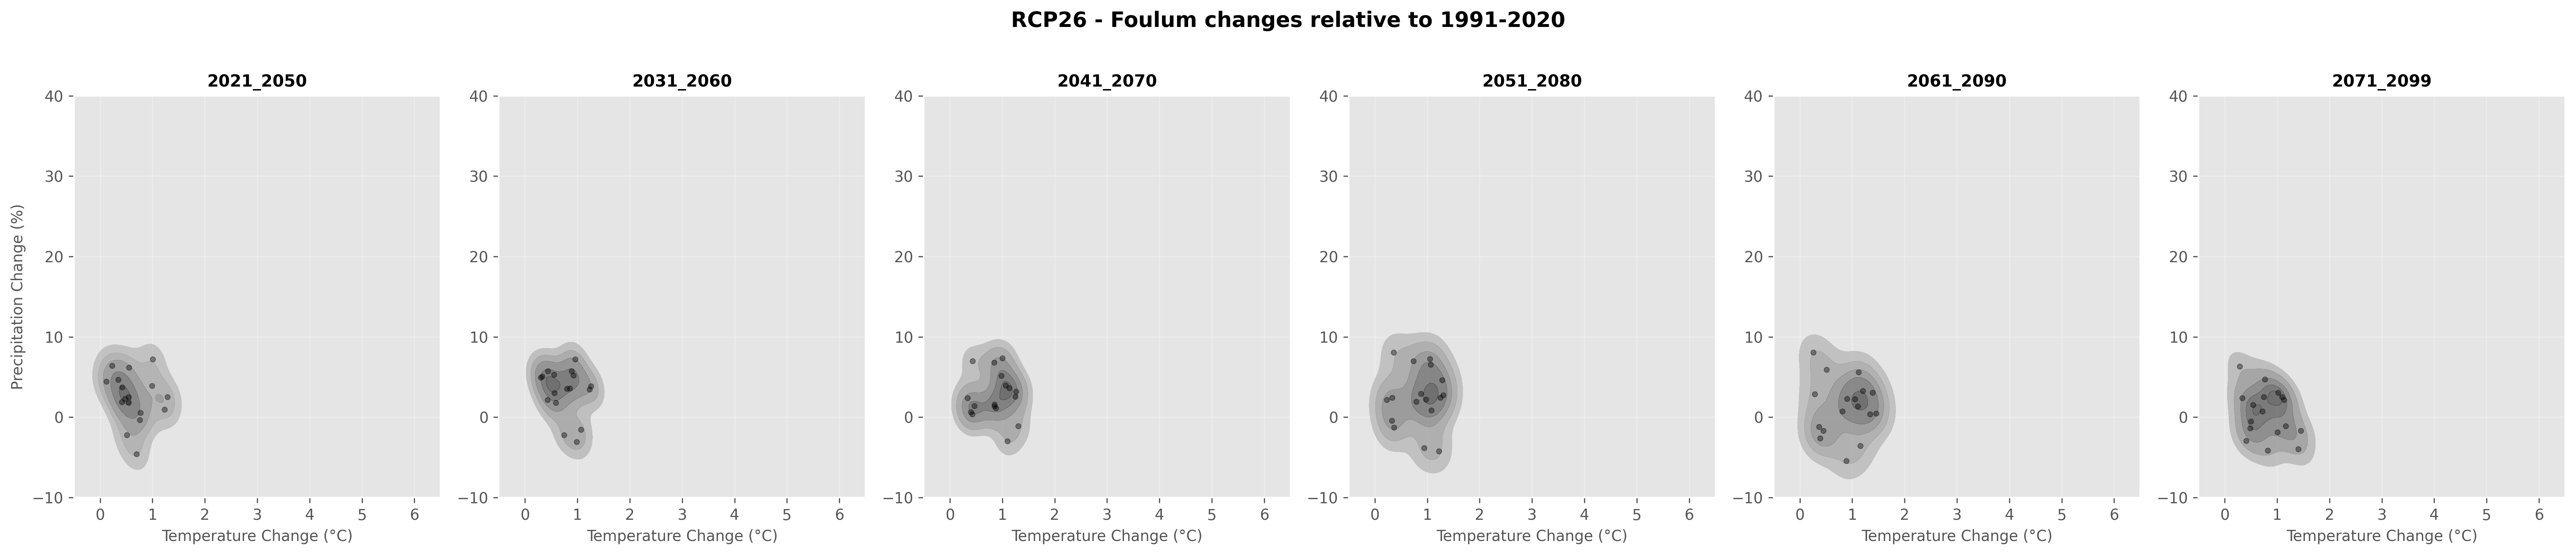

✓ Figura guardada: methodology_outs/scenario_rcp45_all_periods_subplots.png


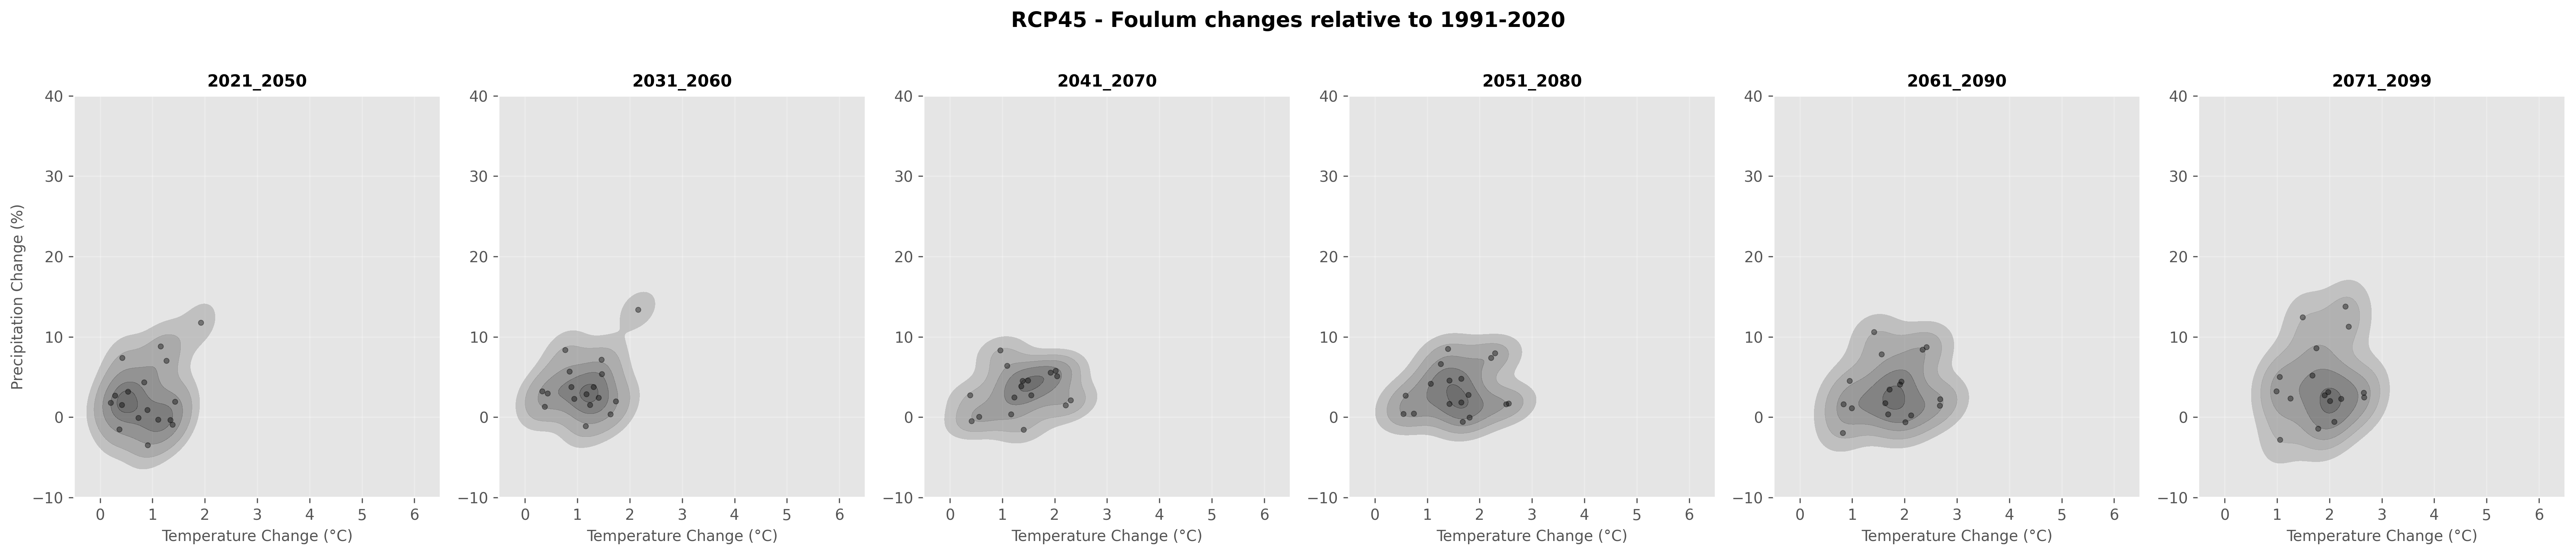

✓ Figura guardada: methodology_outs/scenario_rcp85_all_periods_subplots.png


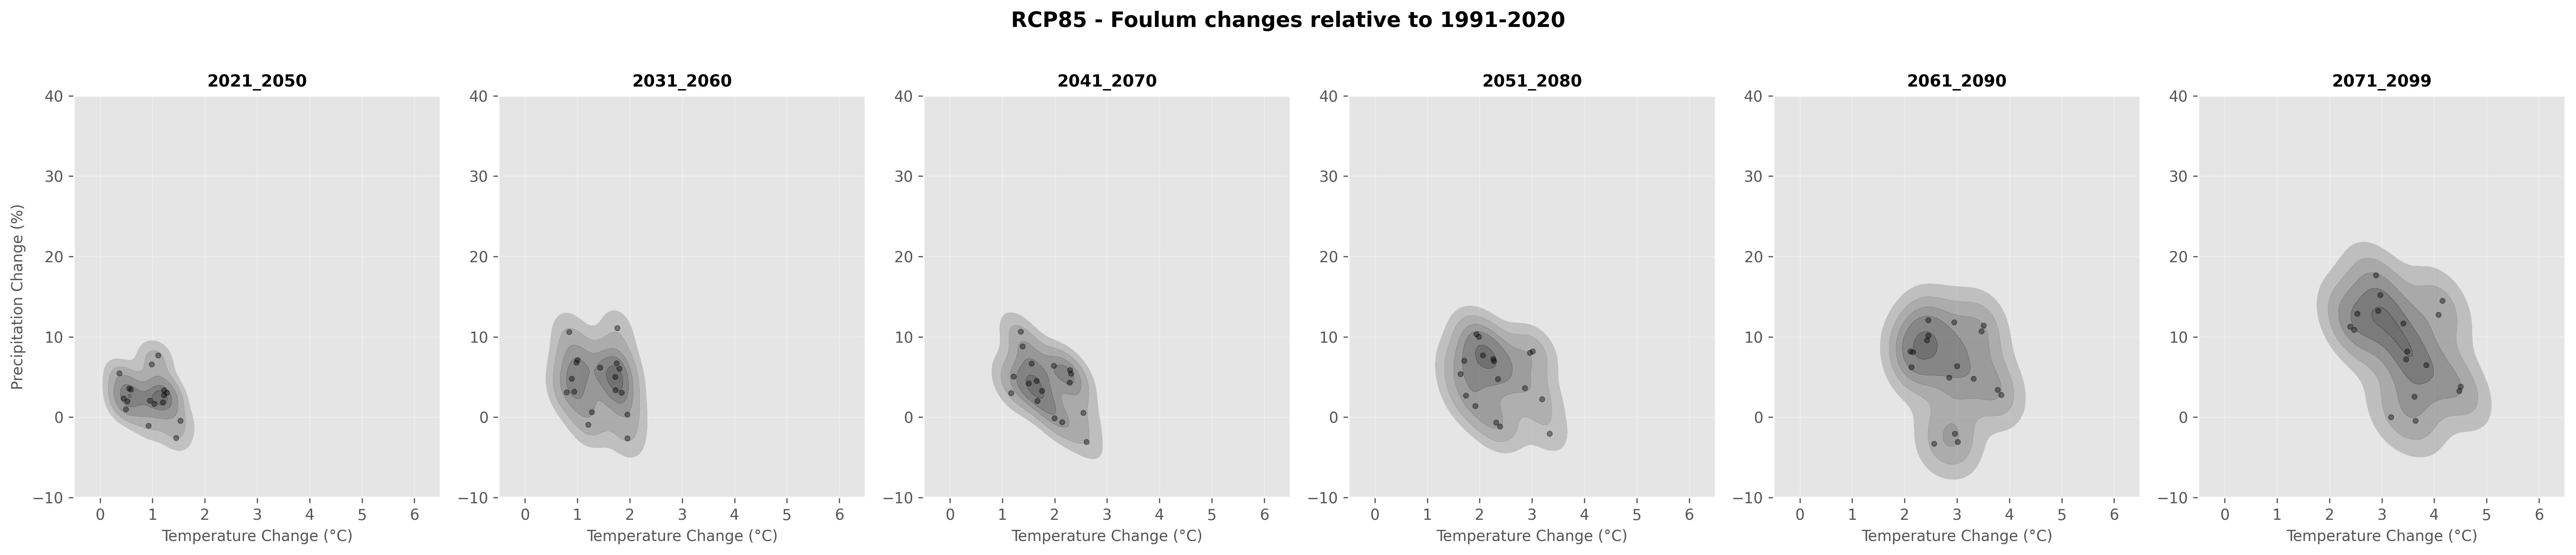

In [4]:
#Subplots

def create_scenario_subplots(scenario, periods, output_dir="methodology_outs"):
    """
    Crea una figura con 6 subplots en una fila, uno por cada período del escenario.
    
    Parámetros:
    - scenario: "rcp26", "rcp45" o "rcp85"
    - periods: lista de períodos
    - output_dir: carpeta donde están los CSV
    """
    
    # Crear figura con subplots (1 fila x 6 columnas)
    fig, axes = plt.subplots(1, 6, figsize=(24, 5), dpi=300)
    
    for idx, period in enumerate(periods):
        ax = axes[idx]
        
        try:
            # Cargar datos
            df_changes = pd.read_csv(f"{output_dir}/{scenario}_{period}_meanChanges_Foulum.csv")
            
            # Crear colormap
            def truncate_colormap(cmap, minval=0.4, maxval=0.9, n=100):
                return LinearSegmentedColormap.from_list(
                    "trunc_greys", cmap(np.linspace(minval, maxval, n))
                )
            trunc_greys = truncate_colormap(plt.cm.Greys, 0.4, 0.9)
            
            # KDE plot en el subplot
            sns.kdeplot(
                x=df_changes['t_change'],
                y=df_changes['pp_change'],
                cmap=trunc_greys,
                fill=True, alpha=0.6,
                levels=[0.1, 0.25, 0.5, 0.75, 0.95, 1],
                thresh=0.0,
                common_norm=False,
                ax=ax
            )
            
            # Scatter points
            ax.scatter(
                df_changes['t_change'],
                df_changes['pp_change'],
                color="k", edgecolor="k", s=12, marker="o", alpha=0.4
            )
            
            ax.set_xlim(-0.5, 6.5)
            ax.set_ylim(-10, 40)
            ax.grid(True, alpha=0.3)
            ax.set_xlabel("Temperature Change (°C)", fontsize=10)
            ax.set_title(f"{period}", fontsize=11, fontweight='bold')
            
            # Solo ylabel en el primer subplot (izquierda)
            if idx == 0:
                ax.set_ylabel("Precipitation Change (%)", fontsize=10)
            else:
                ax.set_ylabel("")
            
        except FileNotFoundError:
            ax.text(0.5, 0.5, f"Archivo no encontrado\n{scenario}_{period}", 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{period} - ERROR", fontsize=11, color='red')
    
    # Título general
    fig.suptitle(f"{scenario.upper()} - Foulum changes relative to 1991-2020", 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    # Guardar figura
    output_path = f"{output_dir}/scenario_{scenario}_all_periods_subplots.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Figura guardada: {output_path}")
    plt.show()


# Ejecutar para cada escenario
scenarios = ["rcp26", "rcp45", "rcp85"]
periods = ["2021_2050", "2031_2060", "2041_2070", "2051_2080", "2061_2090", "2071_2099"]

for scenario in scenarios:
    create_scenario_subplots(scenario, periods)

/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59047/1208804057.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=9)


✓ Figura guardada: methodology_outs/scenario_rcp45_with_contours_subplots.png


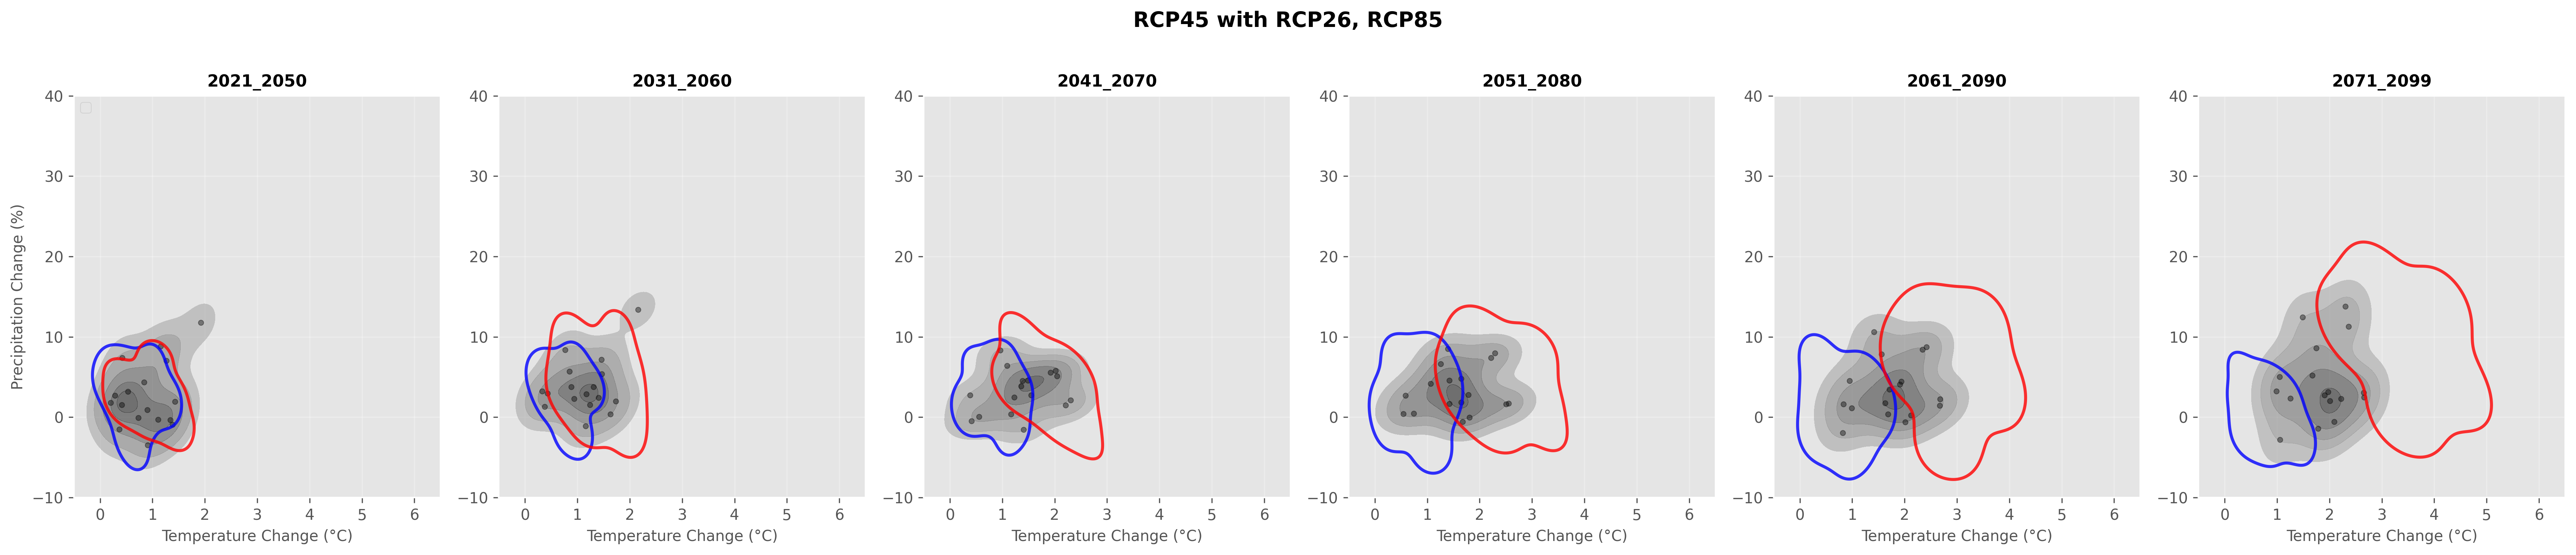

In [5]:
def create_scenario_subplots_with_contours(scenario_main, scenarios_overlay, periods, output_dir="methodology_outs"):
    """
    Crea figura con 6 subplots para scenario_main, con contornos de scenarios_overlay superpuestos.
    
    Parámetros:
    - scenario_main: escenario principal (ej: "rcp45")
    - scenarios_overlay: lista de escenarios a superponer (ej: ["rcp26", "rcp85"])
    - periods: lista de períodos
    - output_dir: carpeta donde están los CSV
    """
    
    # Crear figura con subplots (1 fila x 6 columnas)
    fig, axes = plt.subplots(1, 6, figsize=(24, 5), dpi=300)
    
    # Colores para los escenarios superpuestos
    colors_overlay = {"rcp26": "blue", "rcp85": "red"}
    
    for idx, period in enumerate(periods):
        ax = axes[idx]
        
        try:
            # Crear colormap
            def truncate_colormap(cmap, minval=0.4, maxval=0.9, n=100):
                return LinearSegmentedColormap.from_list(
                    "trunc_greys", cmap(np.linspace(minval, maxval, n))
                )
            trunc_greys = truncate_colormap(plt.cm.Greys, 0.4, 0.9)
            
            # Cargar datos del escenario principal
            df_main = pd.read_csv(f"{output_dir}/{scenario_main}_{period}_meanChanges_Foulum.csv")
            
            # KDE plot del escenario principal
            sns.kdeplot(
                x=df_main['t_change'],
                y=df_main['pp_change'],
                cmap=trunc_greys,
                fill=True, alpha=0.6,
                levels=[0.1, 0.25, 0.5, 0.75, 0.95, 1],
                thresh=0.0,
                common_norm=False,
                ax=ax
            )
            
            # Scatter points del escenario principal
            ax.scatter(
                df_main['t_change'],
                df_main['pp_change'],
                color="k", edgecolor="k", s=12, marker="o", alpha=0.4
            )
            
            # Superponer contornos de escenarios overlay
            for scenario_overlay in scenarios_overlay:
                df_overlay = pd.read_csv(f"{output_dir}/{scenario_overlay}_{period}_meanChanges_Foulum.csv")
                
                # Plotear el contorno más externo (nivel máximo)
                sns.kdeplot(
                    x=df_overlay['t_change'],
                    y=df_overlay['pp_change'],
                    ax=ax,
                    color=colors_overlay[scenario_overlay],
                    linewidths=2,
                    levels=[0.1],  # Solo la línea más exterior
                    alpha=0.8,
                    label=scenario_overlay.upper()
                )
            
            ax.set_xlim(-0.5, 6.5)
            ax.set_ylim(-10, 40)
            ax.grid(True, alpha=0.3)
            ax.set_xlabel("Temperature Change (°C)", fontsize=10)
            ax.set_title(f"{period}", fontsize=11, fontweight='bold')
            
            # Solo ylabel en el primer subplot
            if idx == 0:
                ax.set_ylabel("Precipitation Change (%)", fontsize=10)
            else:
                ax.set_ylabel("")
            
            # Leyenda solo en el primer subplot
            if idx == 0:
                ax.legend(loc='upper left', fontsize=9)
            
        except FileNotFoundError as e:
            ax.text(0.5, 0.5, f"Archivo no encontrado\n{period}", 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{period} - ERROR", fontsize=11, color='red')
    
    # Título general
    fig.suptitle(f"{scenario_main.upper()} with {', '.join([s.upper() for s in scenarios_overlay])}", 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    # Guardar figura
    output_path = f"{output_dir}/scenario_{scenario_main}_with_contours_subplots.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Figura guardada: {output_path}")
    plt.show()


# Ejecutar: RCP4.5 con contornos de RCP2.6 y RCP8.5
periods = ["2021_2050", "2031_2060", "2041_2070", "2051_2080", "2061_2090", "2071_2099"]
create_scenario_subplots_with_contours(
    scenario_main="rcp45",
    scenarios_overlay=["rcp26", "rcp85"],
    periods=periods
)

✓ Figure saved: methodology_outs/scenario_rcp45_with_contours_subplots.png


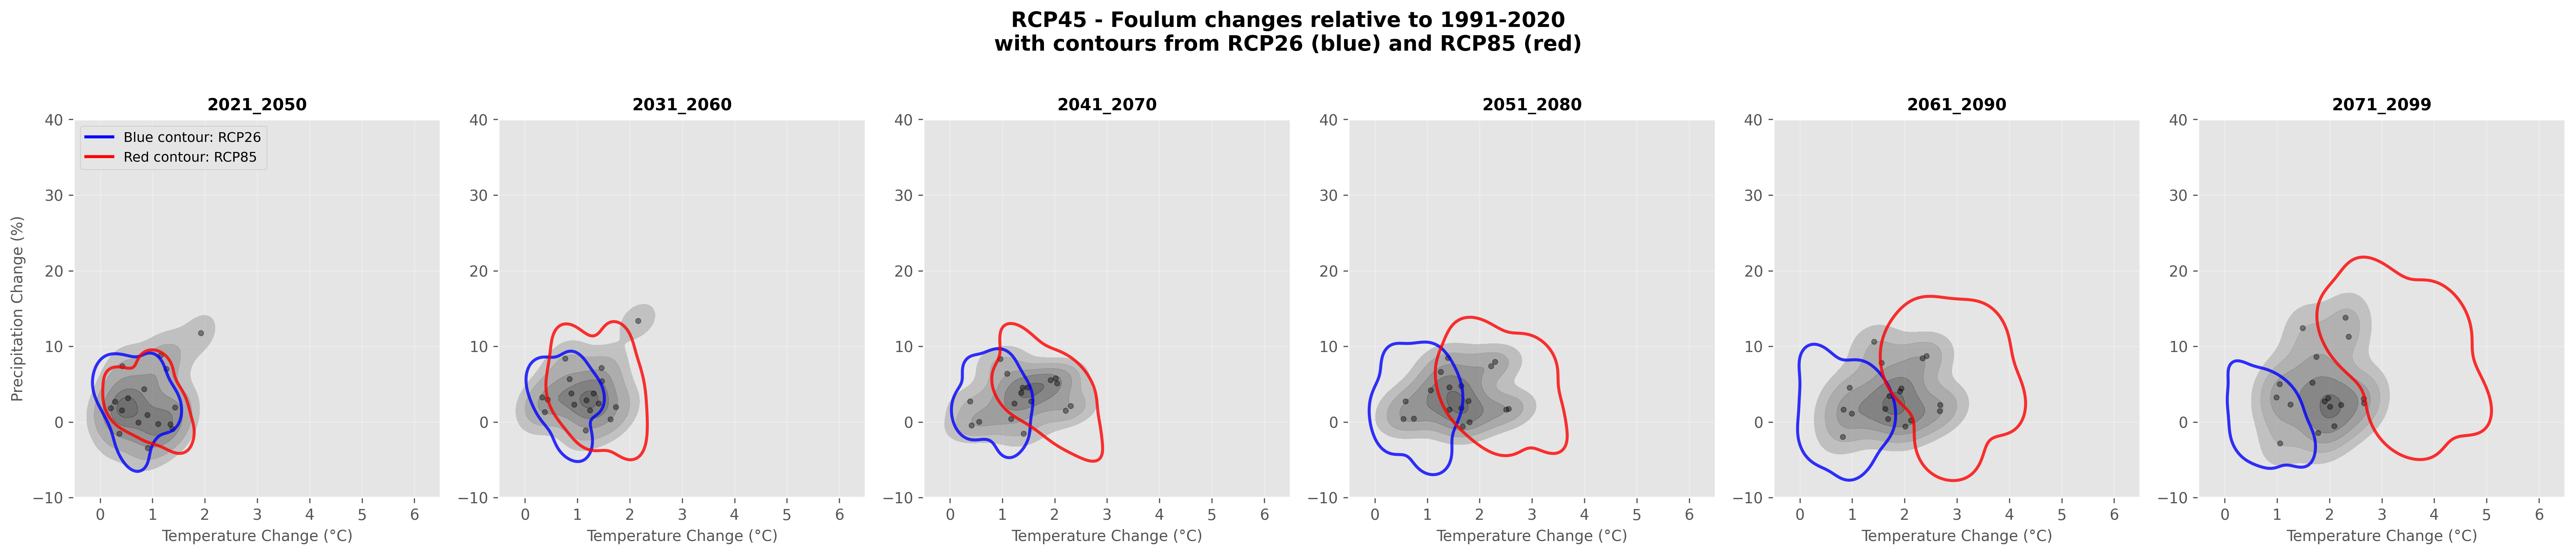

In [6]:
def create_scenario_subplots_with_contours(scenario_main, scenarios_overlay, periods, output_dir="methodology_outs"):
    """
    Creates a figure with 6 subplots for scenario_main, with contours from scenarios_overlay overlaid.
    
    Parameters:
    - scenario_main: main scenario (e.g., "rcp45")
    - scenarios_overlay: list of scenarios to overlay (e.g., ["rcp26", "rcp85"])
    - periods: list of periods
    - output_dir: folder where CSV files are located
    """
    
    # Create figure with subplots (1 row x 6 columns)
    fig, axes = plt.subplots(1, 6, figsize=(24, 5), dpi=300)
    
    # Colors for overlay scenarios
    colors_overlay = {"rcp26": "blue", "rcp85": "red"}
    
    for idx, period in enumerate(periods):
        ax = axes[idx]
        
        try:
            # Create colormap
            def truncate_colormap(cmap, minval=0.4, maxval=0.9, n=100):
                return LinearSegmentedColormap.from_list(
                    "trunc_greys", cmap(np.linspace(minval, maxval, n))
                )
            trunc_greys = truncate_colormap(plt.cm.Greys, 0.4, 0.9)
            
            # Load main scenario data
            df_main = pd.read_csv(f"{output_dir}/{scenario_main}_{period}_meanChanges_Foulum.csv")
            
            # KDE plot of main scenario
            sns.kdeplot(
                x=df_main['t_change'],
                y=df_main['pp_change'],
                cmap=trunc_greys,
                fill=True, alpha=0.6,
                levels=[0.1, 0.25, 0.5, 0.75, 0.95, 1],
                thresh=0.0,
                common_norm=False,
                ax=ax
            )
            
            # Scatter points of main scenario
            ax.scatter(
                df_main['t_change'],
                df_main['pp_change'],
                color="k", edgecolor="k", s=12, marker="o", alpha=0.4
            )
            
            # Overlay contours from overlay scenarios
            for scenario_overlay in scenarios_overlay:
                df_overlay = pd.read_csv(f"{output_dir}/{scenario_overlay}_{period}_meanChanges_Foulum.csv")
                
                # Plot outermost contour (maximum level)
                sns.kdeplot(
                    x=df_overlay['t_change'],
                    y=df_overlay['pp_change'],
                    ax=ax,
                    color=colors_overlay[scenario_overlay],
                    linewidths=2,
                    levels=[0.1],  # Only outer line
                    alpha=0.8
                )
            
            ax.set_xlim(-0.5, 6.5)
            ax.set_ylim(-10, 40)
            ax.grid(True, alpha=0.3)
            ax.set_xlabel("Temperature Change (°C)", fontsize=10)
            ax.set_title(f"{period}", fontsize=11, fontweight='bold')
            
            # Ylabel only on first subplot
            if idx == 0:
                ax.set_ylabel("Precipitation Change (%)", fontsize=10)
            else:
                ax.set_ylabel("")
            
            # Custom legend only on first subplot
            if idx == 0:
                from matplotlib.lines import Line2D
                legend_elements = [
                    Line2D([0], [0], color='blue', linewidth=2, label='Blue contour: RCP26'),
                    Line2D([0], [0], color='red', linewidth=2, label='Red contour: RCP85')
                ]
                ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.95)
            
        except FileNotFoundError as e:
            ax.text(0.5, 0.5, f"File not found\n{period}", 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{period} - ERROR", fontsize=11, color='red')
    
    # General title
    fig.suptitle(f"{scenario_main.upper()} - Foulum changes relative to 1991-2020\nwith contours from RCP26 (blue) and RCP85 (red)", 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    # Save figure
    output_path = f"{output_dir}/scenario_{scenario_main}_with_contours_subplots.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Figure saved: {output_path}")
    plt.show()


# Execute: RCP4.5 with contours from RCP2.6 and RCP8.5
periods = ["2021_2050", "2031_2060", "2041_2070", "2051_2080", "2061_2090", "2071_2099"]
create_scenario_subplots_with_contours(
    scenario_main="rcp45",
    scenarios_overlay=["rcp26", "rcp85"],
    periods=periods
)